# Not Yet Priced In — Demo Notebook
**Team 10 · Big Data Trends & Market Analysis · 2023 8-K Corpus**

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import yfinance as yf
import json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.spines.top':False,'axes.spines.right':False})

DATA_DIR = Path('../data')
watchlist = pd.read_csv(DATA_DIR / 'watchlist_final.csv')
calib     = pd.read_csv(DATA_DIR / 'calibration_table.csv')
master    = pd.read_csv(DATA_DIR / 'master_scored.csv')

print(f'Loaded: {len(master)} filings, {len(watchlist)} watchlist, {len(calib)} calib rows')
print(f'Delayed filings in corpus: {(master["reaction_class"]=="Delayed").sum()}')
print(f'Top MOS score: {master["MOS_retrospective"].max():.3f}')

Loaded: 474 filings, 30 watchlist, 21 calib rows
Delayed filings in corpus: 35
Top MOS score: 0.962


---
## 1  How the System Works

**The problem:** Companies file 8-Ks with material information. The market is supposed to absorb it immediately. Often it doesn't — the stock barely moves at first, then drifts significantly over the following weeks.

**Our system** reads every filing, scores it for information importance, and identifies these delayed reactions. It produces a Missed Opportunity Score (MOS) ranking all 474 filings.

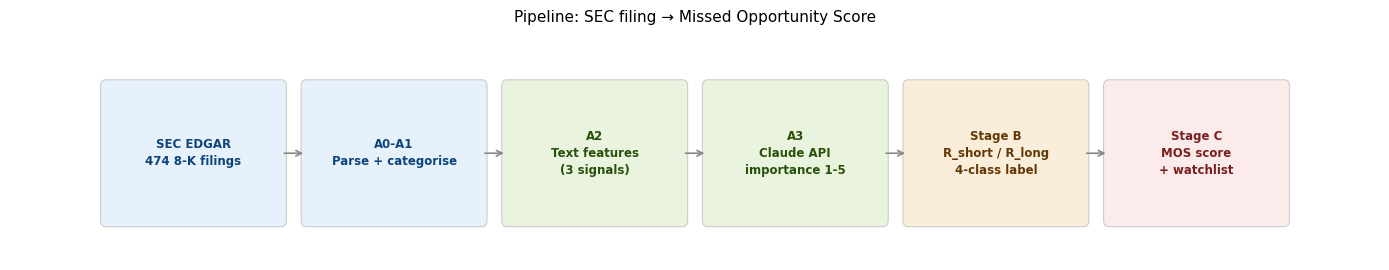

474 filings · 50 companies · 2023 full year
Delayed reactions found: 35 filings (7.4% of corpus)


In [2]:
fig, ax = plt.subplots(figsize=(14, 2.8))
ax.axis('off')

stages = [
    ('SEC EDGAR\n474 8-K filings', '#E6F1FB', '#0C447C'),
    ('A0-A1\nParse + categorise', '#E6F1FB', '#0C447C'),
    ('A2\nText features\n(3 signals)', '#EAF3DE', '#27500A'),
    ('A3\nClaude API\nimportance 1-5', '#EAF3DE', '#27500A'),
    ('Stage B\nR_short / R_long\n4-class label', '#FAEEDA', '#633806'),
    ('Stage C\nMOS score\n+ watchlist', '#FCEBEB', '#791F1F'),
]

box_w, box_h, gap = 1.8, 1.0, 0.25
total_w = len(stages) * box_w + (len(stages)-1) * gap
start_x = (14 - total_w) / 2

for i, (label, fc, tc) in enumerate(stages):
    x = start_x + i * (box_w + gap)
    rect = mpatches.FancyBboxPatch((x, 0.8), box_w, box_h,
        boxstyle='round,pad=0.05', facecolor=fc,
        edgecolor='#cccccc', linewidth=0.8)
    ax.add_patch(rect)
    ax.text(x + box_w/2, 1.3, label, ha='center', va='center',
            fontsize=8.5, color=tc, fontweight='bold', linespacing=1.4)
    if i < len(stages)-1:
        ax.annotate('', xy=(x+box_w+gap, 1.3), xytext=(x+box_w, 1.3),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2))

ax.set_xlim(0, 14)
ax.set_ylim(0.5, 2.2)
ax.set_title('Pipeline: SEC filing → Missed Opportunity Score', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

print('474 filings · 50 companies · 2023 full year')
print(f'Delayed reactions found: {(master["reaction_class"]=="Delayed").sum()} filings ({(master["reaction_class"]=="Delayed").mean():.1%} of corpus)')

---
## 2  Calibration Table — What Does a Delayed Filing Look Like?

Out of 474 filings, 35 were **Delayed** reactions — the market shrugged initially, then moved significantly later.

The table below asks: *for each type of filing, how much more (or less) likely is a Delayed reaction compared to the base rate?*

**Lift ratio** = `P(Delayed | feature) / P(Delayed overall)`. A lift of 3.4x means that type of filing is 3.4 times more likely to be a missed opportunity than a random filing.

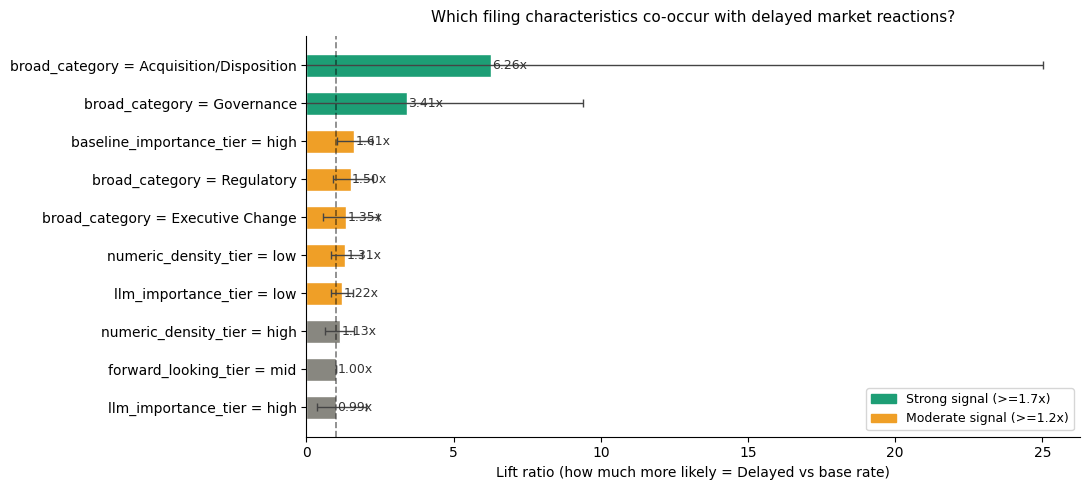

Key findings:
  broad_category = Acquisition/Disposition      lift=6.26x  (3% of Delayed vs 0% overall)
  broad_category = Governance                   lift=3.41x  (9% of Delayed vs 2% overall)
  baseline_importance_tier = high               lift=1.61x  (51% of Delayed vs 32% overall)


In [3]:
show = (
    calib[calib['lift'].notna() & (calib['n_delayed'] >= 1)]
    .sort_values('lift', ascending=False)
    .head(10)
    .copy()
)
show['feature_label'] = show['feature'] + ' = ' + show['value'].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['#1D9E75' if l >= 1.7 else '#EF9F27' if l >= 1.2 else '#888780'
              for l in show['lift']]
bars = ax.barh(show['feature_label'], show['lift'], color=bar_colors, edgecolor='white', height=0.6)
ax.axvline(1.0, color='black', lw=1.2, linestyle='--', alpha=0.5, label='Base rate (lift=1.0)')

for i, (_, row) in enumerate(show.iterrows()):
    if pd.notna(row['ci_95_lo']) and pd.notna(row['ci_95_hi']):
        ax.errorbar(row['lift'], i,
                    xerr=[[row['lift']-row['ci_95_lo']],[row['ci_95_hi']-row['lift']]],
                    fmt='none', color='#444', capsize=3, lw=1)
    ax.text(row['lift']+0.05, i, f"{row['lift']:.2f}x", va='center', fontsize=9, color='#333')

ax.set_xlabel('Lift ratio (how much more likely = Delayed vs base rate)', fontsize=10)
ax.set_title('Which filing characteristics co-occur with delayed market reactions?', fontsize=11, pad=10)
ax.invert_yaxis()
green_p = mpatches.Patch(color='#1D9E75', label='Strong signal (>=1.7x)')
amber_p = mpatches.Patch(color='#EF9F27', label='Moderate signal (>=1.2x)')
ax.legend(handles=[green_p, amber_p], fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print('Key findings:')
top3 = show.head(3)
for _, r in top3.iterrows():
    print(f'  {r["feature_label"]:<45} lift={r["lift"]:.2f}x  '
          f'({r["pct_delayed"]:.0f}% of Delayed vs {r["pct_non_delayed"]:.0f}% overall)')

---
## 3  Case Studies — Real Missed Opportunities

Three filings from our top-30 watchlist. Each one: the market barely moved on day 0–1, but drifted significantly over the following weeks. Our system flagged all three with MOS > 0.90.

In [4]:
def plot_case_study(ticker, filing_date, rank, r_short, r_long,
                    key_signals_raw, reasoning, broad_category, mos):
    try:
        sigs = json.loads(key_signals_raw) if isinstance(key_signals_raw, str) else []
    except Exception:
        sigs = [str(key_signals_raw)]

    # Download 40 days around filing
    fd = pd.Timestamp(filing_date)
    fetch_start = (fd - pd.Timedelta(days=5)).strftime('%Y-%m-%d')
    fetch_end   = (fd + pd.Timedelta(days=30)).strftime('%Y-%m-%d')
    try:
        prices = yf.download(ticker, start=fetch_start, end=fetch_end,
                             auto_adjust=True, progress=False)['Close'].squeeze()
        bench  = yf.download('^GSPC', start=fetch_start, end=fetch_end,
                             auto_adjust=True, progress=False)['Close'].squeeze()
        has_prices = len(prices) > 5
    except Exception:
        has_prices = False

    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4], figure=fig)
    ax_text  = fig.add_subplot(gs[0])
    ax_chart = fig.add_subplot(gs[1])

    # Left panel — filing info
    ax_text.axis('off')
    info = (f'Ticker: {ticker}\n'
            f'Filed: {filing_date}\n'
            f'Category: {broad_category}\n'
            f'MOS: {mos:.3f}\n'
            f'R_short (day 0-1): {r_short*100:+.2f}%\n'
            f'R_long  (day 5-20): {r_long*100:+.2f}%\n\n'
            f'Reasoning:\n{reasoning[:180]}...\n\n'
            f'Key signals from filing:')
    ax_text.text(0.02, 0.98, info, transform=ax_text.transAxes,
                 va='top', ha='left', fontsize=8.5, linespacing=1.5,
                 wrap=True, family='monospace')
    for j, sig in enumerate(sigs[:3]):
        ax_text.text(0.04, 0.30 - j*0.09, f'- "{sig[:70]}..."',
                     transform=ax_text.transAxes, va='top', fontsize=7.8,
                     color='#1D9E75', style='italic', wrap=True)

    # Right panel — price chart
    if has_prices:
        # Normalise to filing date
        filing_ts = prices.index[prices.index >= pd.Timestamp(filing_date)]
        if len(filing_ts) == 0:
            filing_ts = prices.index[-1:]
        base_date = filing_ts[0]
        base_price = prices[base_date]
        base_bench = bench.reindex(prices.index).ffill()[base_date]
        norm_stock = (prices / base_price - 1) * 100
        norm_bench = (bench.reindex(prices.index).ffill() / base_bench - 1) * 100

        ax_chart.plot(norm_stock.index, norm_stock.values, color='#378ADD', lw=2, label=ticker)
        ax_chart.plot(norm_bench.index, norm_bench.values, color='#888780', lw=1,
                      linestyle='--', label='S&P 500')
        ax_chart.axvline(pd.Timestamp(filing_date), color='#E24B4A', lw=1.5,
                         linestyle=':', label='Filing date')
        ax_chart.axhline(0, color='black', lw=0.5, alpha=0.4)
        # Shade the delayed drift window
        try:
            day5_dates  = prices.index[prices.index >= base_date]
            day20_dates = prices.index[prices.index >= base_date]
            if len(day5_dates) > 5 and len(day20_dates) > 20:
                ax_chart.axvspan(day5_dates[5], day20_dates[min(20,len(day20_dates)-1)],
                                 alpha=0.08, color='#EF9F27', label='Days 5-20 (R_long window)')
        except Exception:
            pass
        ax_chart.set_ylabel('Return vs filing date (%)', fontsize=9)
        ax_chart.legend(fontsize=8, loc='lower left')
        ax_chart.set_title(f'{ticker} — price reaction after filing', fontsize=10)
        ax_chart.tick_params(axis='x', labelsize=8, rotation=20)
    else:
        ax_chart.text(0.5, 0.5, 'Price data unavailable\n(run with internet connection)',
                      ha='center', va='center', fontsize=10, color='gray',
                      transform=ax_chart.transAxes)
        ax_chart.axis('off')

    fig.suptitle(f'Rank #{rank} — {ticker} · {filing_date} · {broad_category}',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

print('plot_case_study() ready')

plot_case_study() ready


### Case Study 1 — Boeing (BA) · 2023-12-11
**Executive Change — New COO appointed. Market moved -0.7% on day 0, then drifted -16% over days 5–20.**

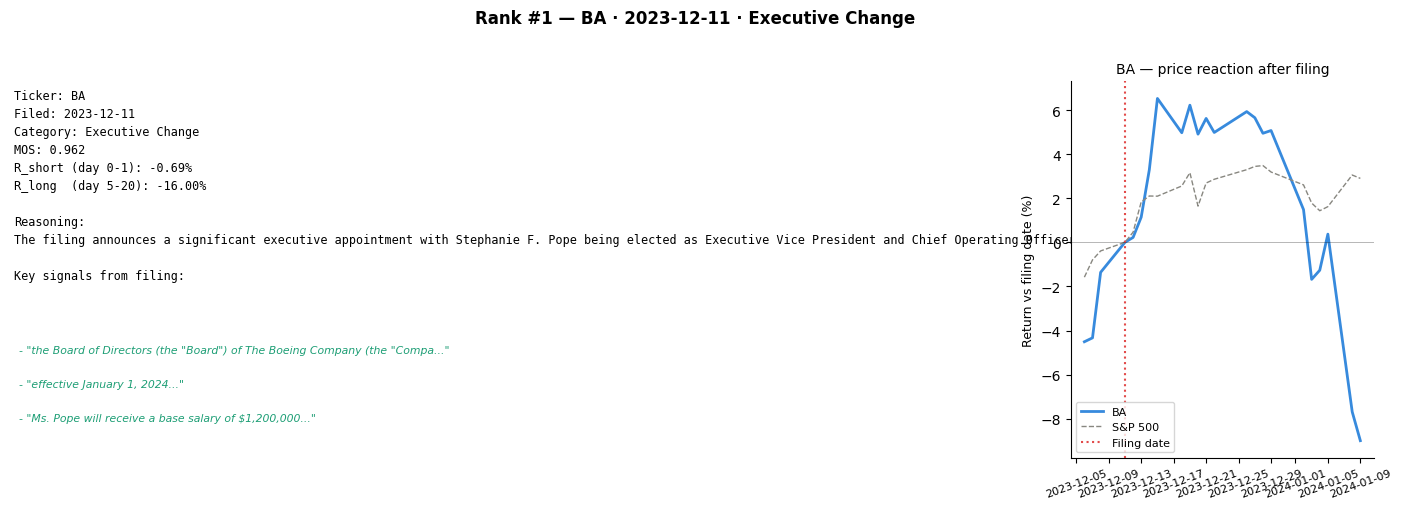

In [5]:
r = watchlist[watchlist['rank']==1].iloc[0]
plot_case_study(
    ticker       = r['ticker'],
    filing_date  = r['filed_date'],
    rank         = int(r['rank']),
    r_short      = r['R_short_0_1'],
    r_long       = r['R_long_5_20'],
    key_signals_raw = r['key_signals'],
    reasoning    = str(r['reasoning']),
    broad_category = r['broad_category'],
    mos          = r['MOS_retrospective'],
)

### Case Study 2 — Costco (COST) · 2023-11-24
**Executive Change — CEO succession announced. Market moved +0.5% on day 0, then drifted +8.7% over days 5–20.**

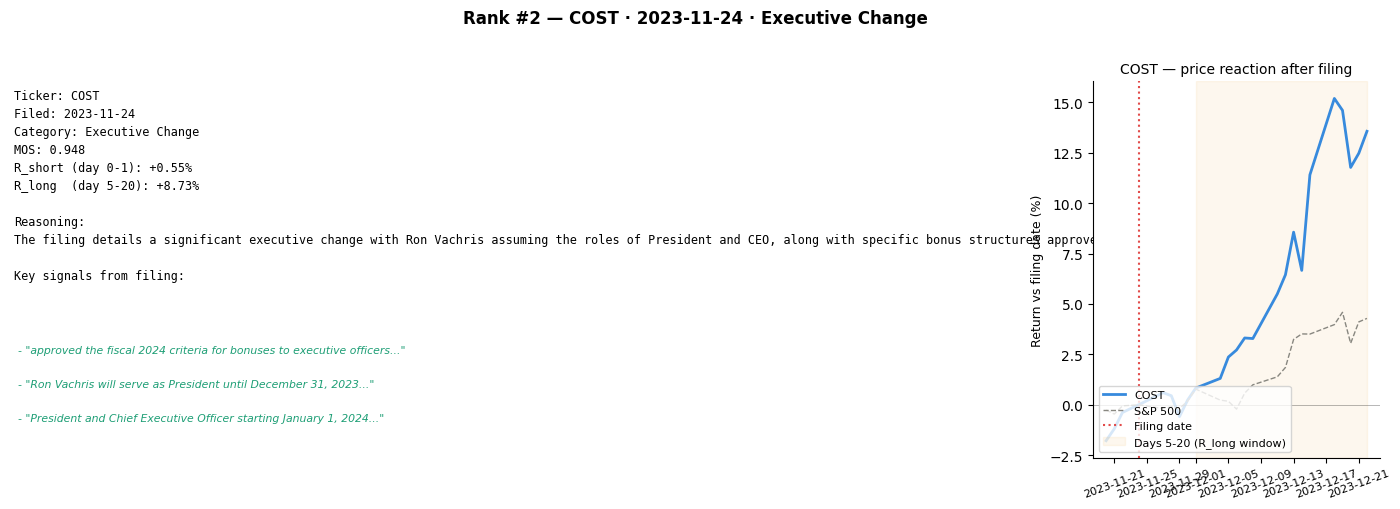

In [6]:
r = watchlist[watchlist['rank']==2].iloc[0]
plot_case_study(
    ticker       = r['ticker'],
    filing_date  = r['filed_date'],
    rank         = int(r['rank']),
    r_short      = r['R_short_0_1'],
    r_long       = r['R_long_5_20'],
    key_signals_raw = r['key_signals'],
    reasoning    = str(r['reasoning']),
    broad_category = r['broad_category'],
    mos          = r['MOS_retrospective'],
)

### Case Study 3 — Microsoft (MSFT) · 2023-01-18
**Regulatory — 10,000 layoffs + $1.2B charge disclosed. Market moved +0.8% on day 0, then drifted +7.3% over days 5–20.**

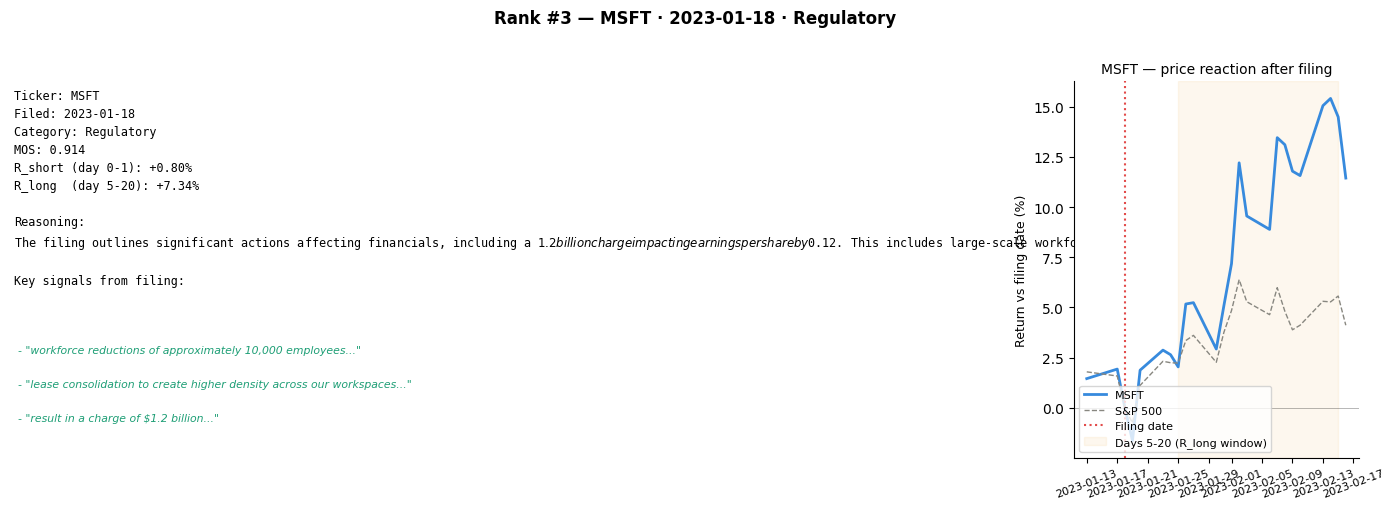

In [7]:
r = watchlist[watchlist['rank']==3].iloc[0]
plot_case_study(
    ticker       = r['ticker'],
    filing_date  = r['filed_date'],
    rank         = int(r['rank']),
    r_short      = r['R_short_0_1'],
    r_long       = r['R_long_5_20'],
    key_signals_raw = r['key_signals'],
    reasoning    = str(r['reasoning']),
    broad_category = r['broad_category'],
    mos          = r['MOS_retrospective'],
)

---
## 4  Top-10 Watchlist

All 474 filings ranked by MOS_retrospective. The top 30 form our watchlist. A high score means: the filing was information-dense AND the market reacted late.

In [8]:
show_cols = ['rank','ticker','filed_date','broad_category',
             'reaction_class','MOS_retrospective','importance_score',
             'R_short_0_1','R_long_5_20']
top10 = watchlist.head(10)[show_cols].copy()
top10['R_short_0_1'] = (top10['R_short_0_1']*100).round(2).astype(str) + '%'
top10['R_long_5_20'] = (top10['R_long_5_20']*100).round(2).astype(str) + '%'
top10['MOS_retrospective'] = top10['MOS_retrospective'].round(3)
top10.columns = ['Rank','Ticker','Date','Category','Reaction','MOS','LLM Score','R_short','R_long']
display(top10.set_index('Rank'))

print(f'Reaction class breakdown in top-30:')
print(watchlist['reaction_class'].value_counts().to_string())

,Ticker,Date,Category,Reaction,MOS,LLM Score,R_short,R_long
Rank,,,,,,,,
1,BA,2023-12-11,Executive Change,Delayed,0.962,5.0,-0.69%,-16.0%
2,COST,2023-11-24,Executive Change,Delayed,0.948,5.0,0.55%,8.73%
3,MSFT,2023-01-18,Regulatory,Delayed,0.914,5.0,0.8%,7.34%
4,JNJ,2023-10-17,Earnings,Delayed,0.897,5.0,-0.23%,-7.46%
5,MSFT,2023-10-13,Acquisition/Disposition,Delayed,0.878,5.0,0.27%,7.38%
6,CVS,2023-10-13,Regulatory,Delayed,0.872,4.0,-0.39%,-6.06%
7,CVS,2023-02-21,Regulatory,Delayed,0.861,4.0,-1.23%,-10.66%
8,MRK,2023-05-17,Regulatory,Delayed,0.856,4.0,-0.16%,-10.02%
9,T,2023-04-20,Regulatory,Delayed,0.841,4.0,-0.73%,-8.98%


Reaction class breakdown in top-30:
reaction_class
Delayed    22
Gradual     8


---
## 5  Live Demo — Score a Brand-New Filing

This is the **prospective** use case: given a fresh 8-K that just dropped, what is the prior probability it will exhibit a delayed reaction?

No market data needed — only the filing's text features.

> **Edit the values in the next cell to score any filing you like.**

In [9]:
# ── Rebuild lift lookup from calibration table ────────────────────────────
lift_lookup = {}
for _, row in calib.iterrows():
    feat = row['feature']
    val  = str(row['value'])
    lift = row['lift'] if pd.notna(row['lift']) else 1.0
    if feat not in lift_lookup:
        lift_lookup[feat] = {}
    lift_lookup[feat][val] = lift

# Tier thresholds from corpus
tier_thresholds = {
    'forward_looking_tier':    (master['forward_looking_density'].quantile(0.33),
                                master['forward_looking_density'].quantile(0.67)),
    'numeric_density_tier':    (master['numeric_density'].quantile(0.33),
                                master['numeric_density'].quantile(0.67)),
    'baseline_importance_tier':(master['baseline_importance'].quantile(0.33),
                                master['baseline_importance'].quantile(0.67)),
    'llm_importance_tier':     (master['llm_importance_norm'].quantile(0.33),
                                master['llm_importance_norm'].quantile(0.67)),
}

prior_scores_corpus = master['MOS_prospective'].dropna().tolist()
print('Lift lookup and tier thresholds ready')
print(f'Corpus size for normalisation: {len(prior_scores_corpus)} filings')

Lift lookup and tier thresholds ready
Corpus size for normalisation: 473 filings


In [10]:
# ── EDIT THESE VALUES to score any new filing ─────────────────────────────
NEW_FILING = {
    'broad_category':           'Executive Change',  # change this
    'importance_score':          5,                  # 1-5 from LLM
    'forward_looking_density':   4.2,               # % forward-looking tokens
    'numeric_density':           8.1,               # % numeric tokens
    'baseline_importance':       0.78,              # 0-1 composite
}
# ──────────────────────────────────────────────────────────────────────────

def get_tier(value, thresholds):
    if pd.isna(value): return 'mid'
    lo, hi = thresholds
    return 'low' if value <= lo else 'high' if value >= hi else 'mid'

def score_filing(f, lift_lookup, tier_thresholds, corpus_scores):
    prior = 1.0
    components = {}
    cat  = str(f.get('broad_category','Other'))
    l = lift_lookup.get('broad_category',{}).get(cat, 1.0)
    prior *= l; components['Category lift'] = l

    imp_norm = (f.get('importance_score',3) - 1) / 4
    tier = get_tier(imp_norm, tier_thresholds['llm_importance_tier'])
    l = lift_lookup.get('llm_importance_tier',{}).get(tier, 1.0)
    prior *= l; components['LLM importance lift'] = l

    tier = get_tier(f.get('forward_looking_density',0), tier_thresholds['forward_looking_tier'])
    l = lift_lookup.get('forward_looking_tier',{}).get(tier, 1.0)
    prior *= l; components['Forward-looking lift'] = l

    tier = get_tier(f.get('numeric_density',0), tier_thresholds['numeric_density_tier'])
    l = lift_lookup.get('numeric_density_tier',{}).get(tier, 1.0)
    prior *= l; components['Numeric density lift'] = l

    tier = get_tier(f.get('baseline_importance',0.5), tier_thresholds['baseline_importance_tier'])
    l = lift_lookup.get('baseline_importance_tier',{}).get(tier, 1.0)
    prior *= l; components['Baseline importance lift'] = l

    rank_pct = float((prior > np.array(corpus_scores)).mean()) if corpus_scores else 0.5
    return prior, rank_pct, components

prior, mos_p, comps = score_filing(NEW_FILING, lift_lookup, tier_thresholds, prior_scores_corpus)

print('=' * 55)
print(f'  MOS_prospective  : {mos_p:.3f}')
print(f'  Interpretation   : Feature profile matches top {(1-mos_p)*100:.0f}% of')
print(f'                     historical Delayed-reaction filings')
print(f'  Raw prior score  : {prior:.4f}')
print('=' * 55)
print()
print('Component lifts:')
for k, v in comps.items():
    bar = '#' * int(v * 10)
    print(f'  {k:<28}: {v:.2f}x  {bar}')

  MOS_prospective  : 1.000
  Interpretation   : Feature profile matches top 0% of
                     historical Delayed-reaction filings
  Raw prior score  : 1.2480

Component lifts:
  Category lift               : 1.35x  #############
  LLM importance lift         : 0.99x  #########
  Forward-looking lift        : 1.00x  ##########
  Numeric density lift        : 0.58x  #####
  Baseline importance lift    : 1.61x  ################


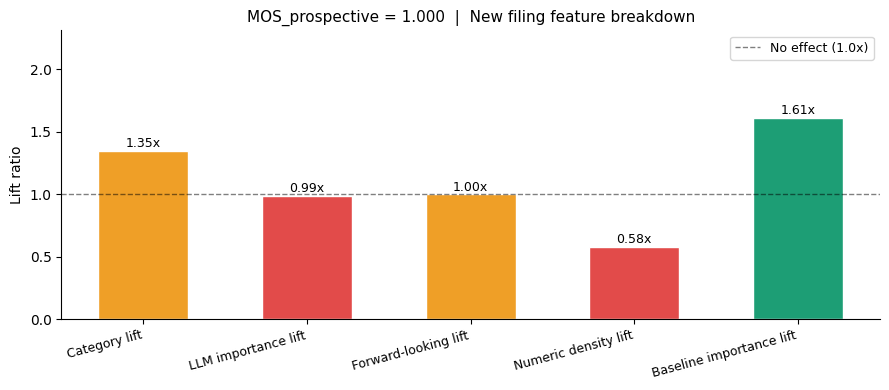

In [11]:
# Waterfall chart of component lifts
fig, ax = plt.subplots(figsize=(9, 4))
feats = list(comps.keys())
vals  = list(comps.values())
colors = ['#1D9E75' if v >= 1.5 else '#EF9F27' if v >= 1.0 else '#E24B4A' for v in vals]
bars = ax.bar(feats, vals, color=colors, edgecolor='white', width=0.55)
ax.axhline(1.0, color='black', lw=1, linestyle='--', alpha=0.5, label='No effect (1.0x)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
            f'{val:.2f}x', ha='center', fontsize=9)
ax.set_ylabel('Lift ratio')
ax.set_title(f'MOS_prospective = {mos_p:.3f}  |  New filing feature breakdown', fontsize=11)
ax.set_ylim(0, max(vals)*1.25 + 0.3)
ax.legend(fontsize=9)
plt.xticks(rotation=15, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6  What's Next — The Live System

The 2023 retrospective analysis you've seen runs on historical data. We've designed and partially built a **live automated pipeline**:

| Layer | What it does | Status |
|---|---|---|
| Ingestion | APScheduler polls SEC EDGAR every 15 min for new 8-K filings | Built |
| Scoring | `parse_filing.py` + A2 features + Claude API runs automatically | Built |
| Alert | If MOS_prospective > 0.65 → Slack / email notification | Built |
| Vector store | Each filing stored as embedding + features + eventual reaction label | Designed |
| ML model | Trains on accumulated labelled rows; improves as corpus grows | Designed |
| Retrain loop | Every N weeks, retrain classifier on all labelled filings | Designed |

**Why not train the ML model now?** 474 filings gives ~35 Delayed cases. That's too small for a robust classifier — any model would overfit. The scheduler is collecting new labelled data every week. In 6–12 months the corpus is 10x larger and the model trains on real ground truth.

**The key insight:** the descriptive calibration table (what you saw in section 2) is already a valid prior. The ML layer makes it sharper as data accumulates — it's a flywheel, not a one-shot build.

In [12]:
# Summary stats for the presentation close
n_total   = len(master)
n_delayed = (master['reaction_class']=='Delayed').sum()
n_watch   = len(watchlist)
top_mos   = master['MOS_retrospective'].max()
top_tick  = master.loc[master['MOS_retrospective'].idxmax(), 'ticker']

print('=' * 50)
print('  SYSTEM SUMMARY')
print('=' * 50)
print(f'  Filings analysed      : {n_total}')
print(f'  Delayed reactions     : {n_delayed} ({n_delayed/n_total:.1%})')
print(f'  Watchlist size        : {n_watch}')
print(f'  Top MOS score         : {top_mos:.3f} ({top_tick})')
print(f'  Strong lift features  : Acquisition/Disposition (6.3x), Governance (3.4x)')
print(f'  Anti-signal features  : Earnings filings (market reacts immediately)')
print('=' * 50)
print()
print('This is decision support, not prediction.')
print('MOS is a flag for analyst review, not a verdict.')

  SYSTEM SUMMARY
  Filings analysed      : 474
  Delayed reactions     : 35 (7.4%)
  Watchlist size        : 30
  Top MOS score         : 0.962 (BA)
  Strong lift features  : Acquisition/Disposition (6.3x), Governance (3.4x)
  Anti-signal features  : Earnings filings (market reacts immediately)

This is decision support, not prediction.
MOS is a flag for analyst review, not a verdict.
